
# Exploração inicial da recombinação molecular

Este notebook tem quatro objetivos:

1. **Entender o tamanho da base de entrada** e quantas estruturas distintas existem.
2. **Medir a multiplicação observada** do algoritmo de recombinação.
3. **Estimar a explosão combinatória teórica** a partir dos fragmentos e posições disponíveis.
4. Representar cada molécula gerada como uma **árvore de recombinação** e comparar duas árvores usando **Tree Edit Distance (Zhang–Shasha)**.

> **Importante:** uma molécula química normalmente é um **grafo**, e não uma árvore, devido a ciclos/anéis.  
> Aqui, Zhang–Shasha será aplicado à **história/receita de recombinação**: anel-base → fragmentos adicionados → posições.  
> Isso permite responder perguntas como: *“quantas operações de inserção, remoção ou substituição separam duas recombinações?”*



## 0. Dependências

O notebook funciona inicialmente apenas com `pandas`, `numpy` e `matplotlib`.

Para a parte de Tree Edit Distance:

```bash
pip install zss
```

Opcionalmente, em uma etapa química posterior, você pode usar RDKit:

```bash
pip install rdkit
```


In [1]:

from pathlib import Path
from itertools import product
from math import prod
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)



## 1. Carregar o CSV

Troque `CAMINHO_CSV` pelo arquivo real.

`sep=None` tenta detectar automaticamente se o arquivo está separado por vírgula, ponto-e-vírgula ou tabulação.


In [2]:
import pandas as pd

CAMINHO_PARQUET = "C:\\Users\\Cliente\\Documents\\Git\\gerador_smiles\\data\\banco_smiles_aromatizados.parquet"

df = pd.read_parquet(CAMINHO_PARQUET)

print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]:,}")

display(df.head())

Linhas: 5,974
Colunas: 34


,id_Anel1,ID_Anel_Anel1,SMILES_Base_Anel1,SMILES_Modificado_Anel1,ID_Frag_1_Anel1,Frag_Estrutura_1_Anel1,Posicao_1_Anel1,ID_Frag_2_Anel1,Frag_Estrutura_2_Anel1,Posicao_2_Anel1,ID_Frag_3_Anel1,Frag_Estrutura_3_Anel1,Posicao_3_Anel1,SMILES_Canonico_Fragmento_Anel1,ID_Ponte,Ponte_Estrutura,id_Anel2,ID_Anel_Anel2,SMILES_Base_Anel2,SMILES_Modificado_Anel2,ID_Frag_1_Anel2,Frag_Estrutura_1_Anel2,Posicao_1_Anel2,ID_Frag_2_Anel2,Frag_Estrutura_2_Anel2,Posicao_2_Anel2,ID_Frag_3_Anel2,Frag_Estrutura_3_Anel2,Posicao_3_Anel2,SMILES_Canonico_Fragmento_Anel2,SMILES_Complexo,SMILES_Canonico_Complexo,SMILES_Aromatico,smiles
0,319,2,C1CCCCC1,C1(N)C(Br)CCC(N(C)C)C1,11,N,2,21,Br,3,1,N(C)C,6,CN(C)C1CCC(Br)C(N)C1,17,C=CC=CC=CC=C,1918,10,C1CCNCC1,C1(CC)CC(C(=O)OCC)NC(C(=O)O)C1,4,CC,2,18,C(=O)OCC,4,14,C(=O)O,6,CCOC(=O)C1CC(CC)CC(C(=O)O)N1,C1(N)C(Br)CCC(N(C)C)C1C=CC=CC=CC=CC2(CC)CC(C(=O)OCC)NC(C(=O)O)C2,CCOC(=O)C1CC(C=CC=CC=CC=CC2C(N)C(Br)CCC2N(C)C)(CC)CC(C(=O)O)N1,CCOC(=O)C1:C:C(C=CC=CC=CC=CC2:C(N(C)C):C:C:C(Br):C:2N)(CC):C:C(C(=O)O):N:1,CCOC(=O)C1:C:C(C=CC=CC=CC=CC2:C(N(C)C):C:C:C(Br):C:2N)(CC):C:C(C(=O)O):N:1
1,8848,45,S1SCCCC1,S1(C(F)(F)F)S(N(CC)CC)CC(NCC)CC1,17,C(F)(F)F,2,9,N(CC)CC,3,23,NCC,5,CCNC1CC[SH](C(F)(F)F)[SH](N(CC)CC)C1,11,C#C,2574,13,C1CCSCC1,C1(C(F)(F)F)C(OC)CSC(Br)C1,17,C(F)(F)F,2,7,OC,3,21,Br,6,COC1CSC(Br)CC1C(F)(F)F,S1(C(F)(F)F)S(N(CC)CC)CC(NCC)CC1C#CC2(C(F)(F)F)C(OC)CSC(Br)C2,CCNC1CC(C#CC2(C(F)(F)F)CC(Br)SCC2OC)[SH](C(F)(F)F)[SH](N(CC)CC)C1,CCNC1:C:C(C#CC2(C(F)(F)F):C:C(Br):S:C:C:2OC):S(C(F)(F)F):S(N(CC)CC):C:1,CCNC1:C:C(C#CC2(C(F)(F)F):C:C(Br):S:C:C:2OC):S(C(F)(F)F):S(N(CC)CC):C:1
2,2142,11,C1CNCCC1,C1CN(Br)C(C(=O)OCC)C(NCC)C1,21,Br,4,18,C(=O)OCC,5,23,NCC,6,CCNC1CCCN(Br)C1C(=O)OCC,19,C(=N),2643,14,C1CSCCC1,C1C(O)S(N=O)C([O][Na])CC1,12,O,3,8,N=O,4,20,[O][Na],5,O=N[SH]1C(O)CCCC1[O][Na],C1CN(Br)C(C(=O)OCC)C(NCC)C1C(=N)C2C(O)S(N=O)C([O][Na])CC2,CCNC1C(C(=N)C2CCC([O][Na])[SH](N=O)C2O)CCN(Br)C1C(=O)OCC,CCNC1:C(C(=N)C2:C:C:C([O][Na]):S(N=O):C:2O):C:C:N(Br):C:1C(=O)OCC,CCNC1:C(C(=N)C2:C:C:C([O][Na]):S(N=O):C:2O):C:C:N(Br):C:1C(=O)OCC
3,6814,35,C1CNCC1,C1(N)CN(S(=O)(=O)O)C(NC(=O)C)C1,11,N,2,22,S(=O)(=O)O,4,13,NC(=O)C,5,CC(=O)NC1CC(N)CN1S(=O)(=O)O,17,C=CC=CC=CC=C,2078,11,C1CNCCC1,C1(N(C)C)C(O)NC(Br)CC1,1,N(C)C,2,12,O,3,21,Br,5,CN(C)C1CCC(Br)NC1O,C1(N)CN(S(=O)(=O)O)C(NC(=O)C)C1C=CC=CC=CC=CC2(N(C)C)C(O)NC(Br)CC2,CC(=O)NC1C(C=CC=CC=CC=CC2(N(C)C)CCC(Br)NC2O)C(N)CN1S(=O)(=O)O,CC(=O)NC1C(C=CC=CC=CC=CC2(N(C)C):C:C:C(Br):N:C:2O)C(N)CN1S(=O)(=O)O,CC(=O)NC1C(C=CC=CC=CC=CC2(N(C)C):C:C:C(Br):N:C:2O)C(N)CN1S(=O)(=O)O
4,5249,27,N1NCCC1,N1(C(=O)O)N(NC(=O)C)CC(N(CC)CC)C1,14,C(=O)O,2,13,NC(=O)C,3,9,N(CC)CC,5,CCN(CC)C1CN(NC(C)=O)N(C(=O)O)C1,1,N=N,4194,21,S1CCSCC1,S1(=O)CC(C(C)C)SC(=N)C1,26,=O,2,24,C(C)C,4,25,=N,6,CC(C)C1CS(=O)CC(=N)S1,N1(C(=O)O)N(NC(=O)C)CC(N(CC)CC)C1N=NS2(=O)CC(C(C)C)SC(=N)C2,CCN(CC)C1CN(NC(C)=O)N(C(=O)O)C1N=N[SH]1(=O)CC(=N)SC(C(C)C)C1,CCN(CC)C1CN(NC(C)=O)N(C(=O)O)C1N=NS1(=O):C:C(C(C)C):S:C(=N):C:1,CCN(CC)C1CN(NC(C)=O)N(C(=O)O)C1N=NS1(=O):C:C(C(C)C):S:C(=N):C:1



## 2. Inspeção das colunas

Como sua tabela possui colunas para `Anel1`, `Anel2`, fragmentos e posições, vamos identificar automaticamente esses grupos.


In [3]:

for i, col in enumerate(df.columns):
    print(f"{i:02d} | {col}")


00 | id_Anel1
01 | ID_Anel_Anel1
02 | SMILES_Base_Anel1
03 | SMILES_Modificado_Anel1
04 | ID_Frag_1_Anel1
05 | Frag_Estrutura_1_Anel1
06 | Posicao_1_Anel1
07 | ID_Frag_2_Anel1
08 | Frag_Estrutura_2_Anel1
09 | Posicao_2_Anel1
10 | ID_Frag_3_Anel1
11 | Frag_Estrutura_3_Anel1
12 | Posicao_3_Anel1
13 | SMILES_Canonico_Fragmento_Anel1
14 | ID_Ponte
15 | Ponte_Estrutura
16 | id_Anel2
17 | ID_Anel_Anel2
18 | SMILES_Base_Anel2
19 | SMILES_Modificado_Anel2
20 | ID_Frag_1_Anel2
21 | Frag_Estrutura_1_Anel2
22 | Posicao_1_Anel2
23 | ID_Frag_2_Anel2
24 | Frag_Estrutura_2_Anel2
25 | Posicao_2_Anel2
26 | ID_Frag_3_Anel2
27 | Frag_Estrutura_3_Anel2
28 | Posicao_3_Anel2
29 | SMILES_Canonico_Fragmento_Anel2
30 | SMILES_Complexo
31 | SMILES_Canonico_Complexo
32 | SMILES_Aromatico
33 | smiles


In [4]:

def cols_contendo(*termos):
    termos = [t.lower() for t in termos]
    return [
        c for c in df.columns
        if all(t in c.lower() for t in termos)
    ]

smiles_cols = [c for c in df.columns if "smiles" in c.lower()]
frag_cols = [c for c in df.columns if "frag_estrutura" in c.lower()]
pos_cols = [c for c in df.columns if "posicao" in c.lower()]
id_frag_cols = [c for c in df.columns if "id_frag" in c.lower()]

print("Colunas SMILES:")
print(smiles_cols)

print("\nColunas de fragmentos:")
print(frag_cols)

print("\nColunas de posição:")
print(pos_cols)


Colunas SMILES:
['SMILES_Base_Anel1', 'SMILES_Modificado_Anel1', 'SMILES_Canonico_Fragmento_Anel1', 'SMILES_Base_Anel2', 'SMILES_Modificado_Anel2', 'SMILES_Canonico_Fragmento_Anel2', 'SMILES_Complexo', 'SMILES_Canonico_Complexo', 'SMILES_Aromatico', 'smiles']

Colunas de fragmentos:
['Frag_Estrutura_1_Anel1', 'Frag_Estrutura_2_Anel1', 'Frag_Estrutura_3_Anel1', 'Frag_Estrutura_1_Anel2', 'Frag_Estrutura_2_Anel2', 'Frag_Estrutura_3_Anel2']

Colunas de posição:
['Posicao_1_Anel1', 'Posicao_2_Anel1', 'Posicao_3_Anel1', 'Posicao_1_Anel2', 'Posicao_2_Anel2', 'Posicao_3_Anel2']



## 3. Qualidade e cardinalidade da base

Antes de falar em multiplicação, precisamos diferenciar:

- número de **linhas geradas**;
- número de **SMILES distintos**;
- número de **SMILES canônicos distintos**;
- duplicatas;
- quantidade de estruturas-base;
- quantidade de fragmentos distintos.

Isso evita confundir “o algoritmo gerou 1 milhão de linhas” com “o algoritmo gerou 1 milhão de moléculas únicas”.


In [5]:

def resumo_coluna(col):
    s = df[col]
    return {
        "coluna": col,
        "linhas_nao_nulas": int(s.notna().sum()),
        "valores_unicos": int(s.nunique(dropna=True)),
        "duplicados": int(s.notna().sum() - s.nunique(dropna=True)),
        "taxa_unicidade": round(s.nunique(dropna=True) / max(s.notna().sum(), 1), 4),
    }

resumo_smiles = pd.DataFrame([resumo_coluna(c) for c in smiles_cols])
display(resumo_smiles)


,coluna,linhas_nao_nulas,valores_unicos,duplicados,taxa_unicidade
0,SMILES_Base_Anel1,5974,48,5926,0.0080
1,SMILES_Modificado_Anel1,5974,3872,2102,0.6481
2,SMILES_Canonico_Fragmento_Anel1,5974,3872,2102,0.6481
3,SMILES_Base_Anel2,5974,36,5938,0.0060
4,SMILES_Modificado_Anel2,5974,3393,2581,0.5680
5,SMILES_Canonico_Fragmento_Anel2,5974,3393,2581,0.5680
6,SMILES_Complexo,5974,5974,0,1.0000
7,SMILES_Canonico_Complexo,5974,5974,0,1.0000
8,SMILES_Aromatico,5974,5974,0,1.0000
9,smiles,5974,5974,0,1.0000


In [6]:

base_cols = [c for c in df.columns if "smiles_base" in c.lower()]

resumo_geral = {
    "linhas_totais": len(df),
    "bases_unicas": {
        c: df[c].nunique(dropna=True)
        for c in base_cols
    },
    "fragmentos_unicos": {
        c: df[c].nunique(dropna=True)
        for c in frag_cols
    }
}

resumo_geral


{'linhas_totais': 5974,
 'bases_unicas': {'SMILES_Base_Anel1': 48, 'SMILES_Base_Anel2': 36},
 'fragmentos_unicos': {'Frag_Estrutura_1_Anel1': 26,
  'Frag_Estrutura_2_Anel1': 26,
  'Frag_Estrutura_3_Anel1': 26,
  'Frag_Estrutura_1_Anel2': 26,
  'Frag_Estrutura_2_Anel2': 26,
  'Frag_Estrutura_3_Anel2': 26}}


## 4. Fator de multiplicação observado

Uma primeira definição simples pode ser:

\[
M_{obs} = \frac{\text{número de moléculas geradas únicas}}
{\text{número de estruturas-base únicas}}
\]

Mas existem várias definições possíveis, dependendo de qual é exatamente a sua **unidade de entrada**.

Por isso, calcularemos algumas versões:

- saída única / `SMILES_Base_Anel1` único;
- saída única / pares únicos `(Anel1, Anel2)`;
- número total de linhas / pares de anéis;
- saída única / combinação de scaffolds-base.


In [7]:

# Escolha automaticamente uma coluna preferencial de saída.
candidatas_saida = [
    "SMILES_Canonico_Complexo",
    "smiles",
    "SMILES_Complexo",
    "SMILES_Aromatico"
]

saida_col = next((c for c in candidatas_saida if c in df.columns), None)

if saida_col is None:
    raise ValueError("Não encontrei automaticamente a coluna de SMILES final.")

n_saida = df[saida_col].nunique(dropna=True)

print("Coluna de saída escolhida:", saida_col)
print("Moléculas finais únicas:", f"{n_saida:,}")


Coluna de saída escolhida: SMILES_Canonico_Complexo
Moléculas finais únicas: 5,974


## 4.1 Validação química global com RDKit

Antes de qualquer análise de árvore/TED, queremos saber: **de toda a base, quantas moléculas são teoricamente válidas** (SMILES parseável pelo RDKit)?

Isso roda uma vez sobre o `df` inteiro (vetorizado) e grava duas colunas novas:

- `smiles_valido_rdkit`: `True`/`False` por linha;
- `smiles_canonico_rdkit`: SMILES canônico recalculado pelo RDKit (ou `None` se inválido).

As linhas inválidas ficam **rastreáveis**: mantemos a receita completa (anéis-base, fragmentos, posições) de cada uma, não só a contagem.


In [8]:
# Rode esta célula uma vez caso rdkit ainda não esteja instalado:
%pip install rdkit


Note: you may need to restart the kernel to use updated packages.


In [9]:
from rdkit import Chem

def smiles_valido_rdkit(smiles):
    if pd.isna(smiles):
        return False
    return Chem.MolFromSmiles(str(smiles)) is not None

def canonizar_rdkit(smiles):
    if pd.isna(smiles):
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

df["smiles_valido_rdkit"] = df[saida_col].apply(smiles_valido_rdkit)
df["smiles_canonico_rdkit"] = df[saida_col].apply(canonizar_rdkit)

n_validas = int(df["smiles_valido_rdkit"].sum())
n_invalidas = len(df) - n_validas

print(f"Coluna de saída avaliada: {saida_col}")
print(f"Moléculas teoricamente válidas (RDKit): {n_validas:,} de {len(df):,} ({n_validas / len(df):.2%})")
print(f"Moléculas inválidas: {n_invalidas:,} ({n_invalidas / len(df):.2%})")

df["smiles_valido_rdkit"].value_counts()


Coluna de saída avaliada: SMILES_Canonico_Complexo
Moléculas teoricamente válidas (RDKit): 5,974 de 5,974 (100.00%)
Moléculas inválidas: 0 (0.00%)


smiles_valido_rdkit
True    5974
Name: count, dtype: int64

In [10]:
# Tabela rastreável das moléculas inválidas: mantém a receita completa (anéis-base,
# fragmentos e posições), não só a contagem.
colunas_rastreio = [
    c for c in (base_cols + frag_cols + pos_cols + [saida_col, "smiles_valido_rdkit"])
    if c in df.columns
]

invalidas_df = df.loc[~df["smiles_valido_rdkit"], colunas_rastreio]

print(f"Moléculas inválidas rastreadas: {len(invalidas_df):,}")
display(invalidas_df.head(20))


Moléculas inválidas rastreadas: 0


,SMILES_Base_Anel1,SMILES_Base_Anel2,Frag_Estrutura_1_Anel1,Frag_Estrutura_2_Anel1,Frag_Estrutura_3_Anel1,Frag_Estrutura_1_Anel2,Frag_Estrutura_2_Anel2,Frag_Estrutura_3_Anel2,Posicao_1_Anel1,Posicao_2_Anel1,Posicao_3_Anel1,Posicao_1_Anel2,Posicao_2_Anel2,Posicao_3_Anel2,SMILES_Canonico_Complexo,smiles_valido_rdkit


In [11]:
# Taxa de validade por estrutura-base: quais anéis-base mais geram moléculas inválidas.
if base_cols:
    resumo_validade_base = (
        df.groupby(base_cols[0])["smiles_valido_rdkit"]
          .agg(total="size", validas="sum")
          .assign(
              invalidas=lambda d: d["total"] - d["validas"],
              taxa_validade=lambda d: d["validas"] / d["total"]
          )
          .sort_values("taxa_validade")
    )
    display(resumo_validade_base)


,total,validas,invalidas,taxa_validade
SMILES_Base_Anel1,,,,
B1CCCCC1,166,166,0,1.0
C1CCCC1,177,177,0,1.0
C1CCCCC1,202,202,0,1.0
C1CCNCC1,186,186,0,1.0
C1CCOCC1,88,88,0,1.0
C1CCSCC1,198,198,0,1.0
C1CNCC1,142,142,0,1.0
C1CNCCC1,189,189,0,1.0
C1COCC1,70,70,0,1.0


In [12]:

metricas_multiplicacao = []

for base_col in base_cols:
    n_base = df[base_col].nunique(dropna=True)
    metricas_multiplicacao.append({
        "entrada": base_col,
        "entradas_unicas": n_base,
        "saidas_unicas": n_saida,
        "multiplicacao_observada": n_saida / max(n_base, 1)
    })

# Se houver duas bases de anel, mede pares.
if len(base_cols) >= 2:
    pares = df[base_cols[:2]].drop_duplicates().shape[0]
    metricas_multiplicacao.append({
        "entrada": f"par({base_cols[0]}, {base_cols[1]})",
        "entradas_unicas": pares,
        "saidas_unicas": n_saida,
        "multiplicacao_observada": n_saida / max(pares, 1)
    })

metricas_multiplicacao = pd.DataFrame(metricas_multiplicacao)
display(metricas_multiplicacao)


,entrada,entradas_unicas,saidas_unicas,multiplicacao_observada
0,SMILES_Base_Anel1,48,5974,124.458333
1,SMILES_Base_Anel2,36,5974,165.944444
2,"par(SMILES_Base_Anel1, SMILES_Base_Anel2)",1426,5974,4.189341



## 5. Fragmentos disponíveis por posição

Agora começa a parte mais interessante para enxergar **quanto a base pode se multiplicar**.

Se uma posição aceita:

- 10 fragmentos na posição A,
- 20 na posição B,
- 5 na posição C,

e as escolhas forem independentes, o limite combinatório ingênuo é:

\[
10 \times 20 \times 5 = 1000
\]

Essa conta é apenas um **upper bound ingênuo**. Na prática, seu algoritmo pode ter:

- fragmentos incompatíveis com determinados anéis;
- posições obrigatórias/opcionais;
- regras de valência;
- fragmentos repetidos;
- simetrias;
- moléculas diferentes que canonicalizam para o mesmo SMILES;
- filtros químicos posteriores.


In [13]:

def extrair_indice_fragmento(nome_col):
    m = re.search(r"Frag_Estrutura_(\d+)_Anel(\d+)", nome_col, flags=re.I)
    if m:
        return int(m.group(2)), int(m.group(1))
    return None

registros = []

for col in frag_cols:
    info = extrair_indice_fragmento(col)
    if info is None:
        continue

    anel, slot = info
    pos_col = f"Posicao_{slot}_Anel{anel}"

    registros.append({
        "anel": anel,
        "slot_fragmento": slot,
        "col_fragmento": col,
        "fragmentos_unicos": df[col].nunique(dropna=True),
        "col_posicao": pos_col if pos_col in df.columns else None,
        "posicoes_unicas": (
            df[pos_col].nunique(dropna=True)
            if pos_col in df.columns else np.nan
        )
    })

fragmentos_por_slot = pd.DataFrame(registros).sort_values(["anel", "slot_fragmento"])
display(fragmentos_por_slot)


,anel,slot_fragmento,col_fragmento,fragmentos_unicos,col_posicao,posicoes_unicas
0,1,1,Frag_Estrutura_1_Anel1,26,Posicao_1_Anel1,3
1,1,2,Frag_Estrutura_2_Anel1,26,Posicao_2_Anel1,3
2,1,3,Frag_Estrutura_3_Anel1,26,Posicao_3_Anel1,3
3,2,1,Frag_Estrutura_1_Anel2,26,Posicao_1_Anel2,3
4,2,2,Frag_Estrutura_2_Anel2,26,Posicao_2_Anel2,3
5,2,3,Frag_Estrutura_3_Anel2,26,Posicao_3_Anel2,3


In [14]:

# Número de pares (posição, fragmento) efetivamente observados em cada slot.
pares_pos_frag = []

for _, row in fragmentos_por_slot.iterrows():
    frag_col = row["col_fragmento"]
    pos_col = row["col_posicao"]

    if pos_col is not None:
        n_pares = (
            df[[pos_col, frag_col]]
            .dropna()
            .drop_duplicates()
            .shape[0]
        )
    else:
        n_pares = df[frag_col].nunique(dropna=True)

    pares_pos_frag.append({
        "anel": row["anel"],
        "slot_fragmento": row["slot_fragmento"],
        "n_escolhas_posicao_fragmento": n_pares
    })

pares_pos_frag = pd.DataFrame(pares_pos_frag)
display(pares_pos_frag)


,anel,slot_fragmento,n_escolhas_posicao_fragmento
0,1,1,78
1,1,2,78
2,1,3,78
3,2,1,78
4,2,2,78
5,2,3,78


In [15]:

# Upper bound ingênuo multiplicando o número de escolhas observadas em cada slot.
upper_bounds = (
    pares_pos_frag
    .groupby("anel")["n_escolhas_posicao_fragmento"]
    .apply(lambda x: int(prod(x)))
    .rename("upper_bound_ingenuo")
    .reset_index()
)

display(upper_bounds)


,anel,upper_bound_ingenuo
0,1,474552
1,2,474552



### Interpretação

Esse `upper_bound_ingenuo` responde:

> “Se eu pudesse combinar livremente todas as escolhas observadas em cada slot, quantas receitas de recombinação seriam possíveis?”

Ele **não garante moléculas válidas**.

Depois podemos tornar essa estimativa muito mais fiel incorporando as regras reais do seu algoritmo.



## 6. Quantas combinações realmente aparecem?

Aqui transformamos os slots de fragmento/posição em uma assinatura da recombinação.

Duas linhas com a mesma assinatura usaram a mesma “receita”, mesmo que existam outras colunas auxiliares.


In [16]:

assinatura_cols = []

for col in frag_cols:
    info = extrair_indice_fragmento(col)
    if info is None:
        continue

    anel, slot = info
    pos_col = f"Posicao_{slot}_Anel{anel}"

    assinatura_cols.append(col)
    if pos_col in df.columns:
        assinatura_cols.append(pos_col)

assinatura_cols = list(dict.fromkeys(assinatura_cols))

n_receitas = df[assinatura_cols].drop_duplicates().shape[0]

print("Slots usados na assinatura:")
print(assinatura_cols)

print(f"\nReceitas de recombinação únicas: {n_receitas:,}")
print(f"Moléculas finais únicas: {n_saida:,}")
print(f"Razão moléculas únicas / receitas únicas: {n_saida / max(n_receitas,1):.4f}")


Slots usados na assinatura:
['Frag_Estrutura_1_Anel1', 'Posicao_1_Anel1', 'Frag_Estrutura_2_Anel1', 'Posicao_2_Anel1', 'Frag_Estrutura_3_Anel1', 'Posicao_3_Anel1', 'Frag_Estrutura_1_Anel2', 'Posicao_1_Anel2', 'Frag_Estrutura_2_Anel2', 'Posicao_2_Anel2', 'Frag_Estrutura_3_Anel2', 'Posicao_3_Anel2']

Receitas de recombinação únicas: 5,974
Moléculas finais únicas: 5,974
Razão moléculas únicas / receitas únicas: 1.0000



## 7. Distribuição: quantas moléculas cada base gera?

Esse gráfico é um dos mais úteis para o início do trabalho.

Ele permite verificar se:

- algumas bases quase não se multiplicam;
- poucas bases concentram enorme parte da geração;
- a distribuição é homogênea ou extremamente assimétrica.


count     48.000000
mean     124.458333
std       59.112571
min       19.000000
25%       68.000000
50%      150.500000
75%      175.250000
max      215.000000
Name: moleculas_unicas_geradas, dtype: float64

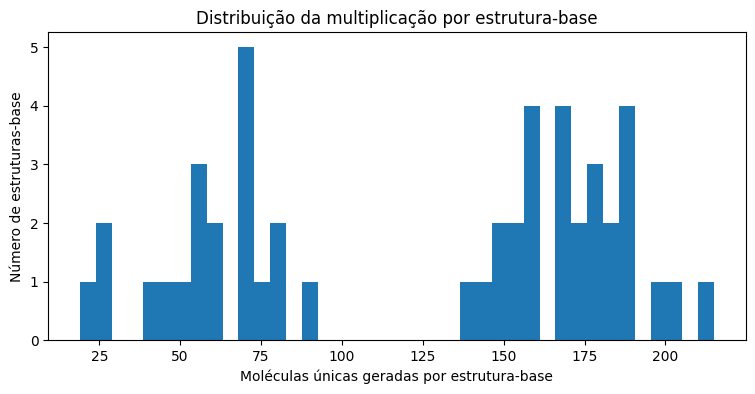

,moleculas_unicas_geradas
SMILES_Base_Anel1,
S1SCCCC1,215
C1CCCCC1,202
C1CCSCC1,198
C1CNCCC1,189
S1CCSCC1,189
C1CSCCC1,189
C1CCNCC1,186
C1SCCCC1,182
S1CCCCC1,182


In [17]:

if base_cols:
    base_col = base_cols[0]

    geradas_por_base = (
        df.groupby(base_col)[saida_col]
          .nunique()
          .sort_values(ascending=False)
          .rename("moleculas_unicas_geradas")
    )

    display(geradas_por_base.describe())

    plt.figure(figsize=(9, 4))
    plt.hist(geradas_por_base.values, bins=40)
    plt.xlabel("Moléculas únicas geradas por estrutura-base")
    plt.ylabel("Número de estruturas-base")
    plt.title("Distribuição da multiplicação por estrutura-base")
    plt.show()

    display(geradas_por_base.head(20).to_frame())



## 8. Crescimento acumulado da diversidade

Isso mostra se adicionar mais linhas ao processo continua trazendo moléculas novas ou se a geração começa a saturar.


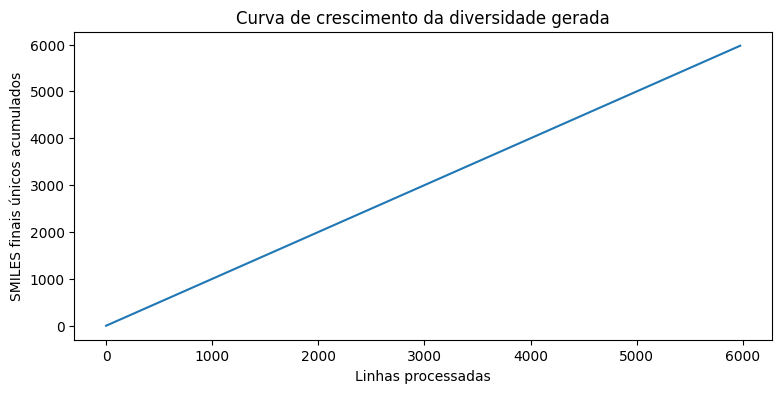

Taxa final de novidade: 1.0


In [18]:

saida_series = df[saida_col].astype("string")

novidade = ~saida_series.duplicated()
acumulado_unicos = novidade.cumsum()

plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(df) + 1), acumulado_unicos)
plt.xlabel("Linhas processadas")
plt.ylabel("SMILES finais únicos acumulados")
plt.title("Curva de crescimento da diversidade gerada")
plt.show()

print(
    "Taxa final de novidade:",
    round(n_saida / max(df[saida_col].notna().sum(), 1), 4)
)



# 9. Zhang–Shasha / Tree Edit Distance

A Tree Edit Distance procura o **menor custo total** necessário para transformar uma árvore em outra.

As operações básicas são:

- **inserir** um nó;
- **remover** um nó;
- **substituir/renomear** um nó.

Se cada operação tiver custo 1, uma distância igual a 3 significa que a transformação mínima custa 3 operações.

No nosso caso, podemos criar algo como:

```text
MOLECULA
├── ANEL1
│   ├── POS_2
│   │   └── N
│   └── POS_3
│       └── Br
└── ANEL2
    ├── POS_4
    │   └── C(=O)OCC
    └── POS_6
        └── C(=O)O
```

Assim, duas moléculas geradas podem ser comparadas pela **diferença entre suas receitas de recombinação**.


In [19]:

# Rode esta célula uma vez caso zss ainda não esteja instalado:
%pip install zss


Note: you may need to restart the kernel to use updated packages.


In [20]:

from zss import Node, simple_distance


In [21]:

def valor_valido(v):
    return pd.notna(v) and str(v).strip() not in {"", "nan", "None"}

def linha_para_arvore(row):
    raiz = Node("MOLECULA")

    for anel in [1, 2]:
        # Tenta achar um identificador/base relevante para o anel.
        candidatos_base = [
            f"SMILES_Base_Anel{anel}",
            f"SMILES_Canonico_Fragmento_Anel{anel}",
            f"ID_Anel_Anel{anel}",
        ]

        base_label = next(
            (
                str(row[c])
                for c in candidatos_base
                if c in row.index and valor_valido(row[c])
            ),
            f"ANEL{anel}"
        )

        no_anel = Node(f"ANEL{anel}:{base_label}")
        raiz.addkid(no_anel)

        # Coleta os fragmentos desse anel e ordena por posição.
        itens = []

        for slot in range(1, 10):
            frag_col = f"Frag_Estrutura_{slot}_Anel{anel}"
            pos_col = f"Posicao_{slot}_Anel{anel}"

            if frag_col not in row.index:
                continue

            frag = row[frag_col]

            if not valor_valido(frag):
                continue

            pos = row[pos_col] if pos_col in row.index else "?"
            itens.append((str(pos), str(frag)))

        # Ordem estável pela posição.
        itens = sorted(itens, key=lambda x: x[0])

        for pos, frag in itens:
            no_pos = Node(f"POS:{pos}")
            no_pos.addkid(Node(f"FRAG:{frag}"))
            no_anel.addkid(no_pos)

    return raiz


In [22]:

# Exemplo: comparar as duas primeiras linhas.
arvore_0 = linha_para_arvore(df.iloc[0])
arvore_1 = linha_para_arvore(df.iloc[1])

distancia = simple_distance(arvore_0, arvore_1)

print("Tree Edit Distance entre linha 0 e linha 1:", distancia)


Tree Edit Distance entre linha 0 e linha 1: 10.0



## 10. Recuperar também as operações

A biblioteca `zss` permite usar a API mais completa para recuperar o custo e o conjunto de operações.

Aqui definimos:

- inserir nó = 1;
- remover nó = 1;
- manter mesmo rótulo = 0;
- substituir rótulo = 1.


In [23]:

from zss import distance

def custo_insercao(node):
    return 1

def custo_remocao(node):
    return 1

def custo_substituicao(a, b):
    return 0 if a.label == b.label else 1

custo, operacoes = distance(
    arvore_0,
    arvore_1,
    get_children=lambda n: n.children,
    insert_cost=custo_insercao,
    remove_cost=custo_remocao,
    update_cost=custo_substituicao,
    return_operations=True
)

print("Custo mínimo:", custo)
print("\nOperações:")
for op in operacoes:
    print(op)


Custo mínimo: 10.0

Operações:
<Operation Update>
<Operation Match>
<Operation Update>
<Operation Match>
<Operation Update>
<Operation Update>
<Operation Update>
<Operation Update>
<Operation Match>
<Operation Update>
<Operation Update>
<Operation Update>
<Operation Match>
<Operation Update>
<Operation Match>



## 11. Distância normalizada

A distância absoluta pode favorecer árvores pequenas.

Uma forma inicial de normalizar é:

\[
d_{norm} = \frac{TED(T_1,T_2)}
{\max(|T_1|,|T_2|)}
\]

Assim, valores próximos de:

- `0` → receitas muito semelhantes;
- `1` → receitas muito diferentes.

Essa normalização é uma escolha metodológica e deve ser justificada no trabalho.


In [24]:

def tamanho_arvore(node):
    return 1 + sum(tamanho_arvore(filho) for filho in node.children)

def ted_normalizada(a, b):
    d = simple_distance(a, b)
    denom = max(tamanho_arvore(a), tamanho_arvore(b), 1)
    return d / denom

print("TED normalizada:", ted_normalizada(arvore_0, arvore_1))


TED normalizada: 0.6666666666666666


## 12. Matriz de distância para uma amostra

**Cuidado:** comparar todas as moléculas contra todas tem crescimento quadrático.

Para `N` moléculas, existem aproximadamente:

`N × (N - 1) / 2`

pares.

Exemplos:

- 100 moléculas → 4.950 pares;
- 1.000 → 499.500 pares;
- 10.000 → 49.995.000 pares.

Por isso começamos com uma amostra.

**Validação química a cada ciclo:** antes de montar a árvore de cada linha, validamos o SMILES de saída com o RDKit (`Chem.MolFromSmiles`). Linhas cujo SMILES não é parseável são descartadas da amostra e não entram na matriz de TED.


In [25]:
N_AMOSTRA = min(100, len(df))

amostra_bruta = df.iloc[:N_AMOSTRA].copy()

arvores = []
indices_validos = []

for idx, row in amostra_bruta.iterrows():
    # Reaproveita a validação RDKit global (Seção 4.1) a cada ciclo do loop:
    # só constrói a árvore se a molécula daquela linha for válida.
    if not row["smiles_valido_rdkit"]:
        continue

    arvores.append(linha_para_arvore(row))
    indices_validos.append(idx)

invalidas_amostra = amostra_bruta.loc[
    ~amostra_bruta.index.isin(indices_validos),
    [saida_col, "smiles_valido_rdkit"]
]

print(f"Moléculas inválidas (RDKit) descartadas da amostra: {len(invalidas_amostra)} de {N_AMOSTRA}")
display(invalidas_amostra)

amostra = amostra_bruta.loc[indices_validos]
N_VALIDAS = len(amostra)

matriz_ted = np.zeros((N_VALIDAS, N_VALIDAS), dtype=float)

for i in range(N_VALIDAS):
    for j in range(i + 1, N_VALIDAS):
        d = ted_normalizada(arvores[i], arvores[j])
        matriz_ted[i, j] = d
        matriz_ted[j, i] = d

matriz_ted_df = pd.DataFrame(
    matriz_ted,
    index=amostra.index,
    columns=amostra.index
)

display(matriz_ted_df.iloc[:10, :10])


Moléculas inválidas (RDKit) descartadas da amostra: 0 de 100


,SMILES_Canonico_Complexo,smiles_valido_rdkit


,0,1,2,3,4,5,6,7,8,9
0,0.000000,0.666667,0.800000,0.733333,0.600000,0.733333,0.800000,0.600000,0.666667,0.800000
1,0.666667,0.000000,0.866667,0.600000,0.600000,0.733333,0.800000,0.733333,0.666667,0.666667
2,0.800000,0.866667,0.000000,0.866667,0.866667,0.733333,0.800000,0.666667,0.800000,0.933333
3,0.733333,0.600000,0.866667,0.000000,0.733333,0.733333,0.933333,0.733333,0.533333,0.666667
4,0.600000,0.600000,0.866667,0.733333,0.000000,0.800000,0.866667,0.533333,0.600000,0.666667
5,0.733333,0.733333,0.733333,0.733333,0.800000,0.000000,0.666667,0.800000,0.800000,0.666667
6,0.800000,0.800000,0.800000,0.933333,0.866667,0.666667,0.000000,0.866667,0.800000,0.733333
7,0.600000,0.733333,0.666667,0.733333,0.533333,0.800000,0.866667,0.000000,0.733333,0.733333
8,0.666667,0.666667,0.800000,0.533333,0.600000,0.800000,0.800000,0.733333,0.000000,0.600000
9,0.800000,0.666667,0.933333,0.666667,0.666667,0.666667,0.733333,0.733333,0.600000,0.000000


In [26]:

# Para cada molécula, encontra a molécula mais próxima na amostra.
np.fill_diagonal(matriz_ted, np.inf)

vizinho_idx = matriz_ted.argmin(axis=1)
vizinho_dist = matriz_ted.min(axis=1)

mais_proximos = pd.DataFrame({
    "linha": amostra.index,
    "linha_mais_proxima": [amostra.index[j] for j in vizinho_idx],
    "TED_normalizada": vizinho_dist
}).sort_values("TED_normalizada")

display(mais_proximos.head(20))


,linha,linha_mais_proxima,TED_normalizada
14,14,85,0.400000
35,35,60,0.400000
60,60,35,0.400000
85,85,14,0.400000
74,74,64,0.400000
79,79,66,0.400000
66,66,79,0.400000
64,64,74,0.400000
15,15,10,0.466667
10,10,15,0.466667



# 13. Perguntas que este notebook já consegue responder

Depois de carregar seu CSV completo, você passa a conseguir medir:

1. Quantas linhas o algoritmo produziu?
2. Quantas moléculas finais são realmente únicas?
3. Quantos scaffolds/anéis distintos existiam na entrada?
4. Quantos fragmentos distintos existem por slot?
5. Quantas combinações `(posição, fragmento)` existem?
6. Qual seria a explosão combinatória ingênua?
7. Qual é a multiplicação realmente observada?
8. Qual percentual das tentativas resulta em estruturas redundantes?
9. Quais estruturas-base mais geram diversidade?
10. A diversidade continua crescendo ou começa a saturar?
11. Quais duas receitas de recombinação são mais parecidas?
12. Quantas inserções, remoções e substituições separam duas receitas?



# 14. Próximas etapas metodológicas

Para o mestrado, eu separaria a análise em três níveis:

### Nível A — Espaço combinatório
Quantificar o quanto as regras de recombinação expandem a base inicial.

### Nível B — Distância de processo
Usar Tree Edit Distance para medir quão diferentes são as **árvores de recombinação**.

### Nível C — Distância química
Comparar as moléculas finais de fato, por exemplo com:

- fingerprints moleculares + similaridade de Tanimoto;
- Maximum Common Substructure (MCS);
- Graph Edit Distance;
- descritores físico-químicos.

Isso é importante porque duas receitas de recombinação muito diferentes podem eventualmente produzir estruturas químicas semelhantes, e o contrário também pode acontecer.


## 15. Validação química com RDKit — visão vetorizada no df inteiro

A validação por ciclo já foi incorporada na **Seção 12** (a árvore só é construída se `Chem.MolFromSmiles` aceitar o SMILES daquela linha). Aqui fica uma versão vetorizada, útil para checar a validade de **todo** o `df`, não só da amostra usada no TED:

```python
from rdkit import Chem

def smiles_valido(s):
    if pd.isna(s):
        return False
    return Chem.MolFromSmiles(str(s)) is not None

df["smiles_valido"] = df[saida_col].apply(smiles_valido)

df["smiles_valido"].value_counts()
```

Também podemos recalcular o SMILES canônico usando RDKit, em vez de depender apenas da coluna já existente.
